In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import lightgbm as lgb

In [2]:
TRAIN_DATA=pd.read_csv("../data/processed/train.csv")
VAL_DATA=pd.read_csv("../data/processed/val.csv")
TEST_DATA=pd.read_csv("../data/processed/test.csv")

In [3]:
TRAIN_DATA.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   latitude                       19165 non-null  float64
 1   longitude                      19165 non-null  float64
 2   city_id                        19165 non-null  int64  
 3   weather_code                   19165 non-null  int64  
 4   temp_mean_c                    19165 non-null  float64
 5   temp_max_c                     19165 non-null  float64
 6   temp_min_c                     19165 non-null  float64
 7   wind_speed_max_kmh             19165 non-null  float64
 8   wind_gusts_max_kmh             19165 non-null  float64
 9   shortwave_radiation_sum_mj_m2  19165 non-null  float64
 10  daylight_duration_s            19165 non-null  float64
 11  precipitation_sum_mm           19165 non-null  float64
 12  cloud_cover_mean_pct           19165 non-null  float64
 1

In [4]:
# Define the exact schema mapping
dtype_mapping = {
    'latitude': 'float64',
    'longitude': 'float64',
    'city_id': 'category',
    'weather_code': 'category',
    'temp_mean_c': 'float64',
    'temp_max_c': 'float64',
    'temp_min_c': 'float64',
    'wind_speed_max_kmh': 'float64',
    'wind_gusts_max_kmh': 'float64',
    'shortwave_radiation_sum_mj_m2': 'float64',
    'daylight_duration_s': 'float64',
    'precipitation_sum_mm': 'float64',
    'cloud_cover_mean_pct': 'float64',
    'dew_point_mean_c': 'float64',
    'dew_point_max_c': 'float64',
    'dew_point_min_c': 'float64',
    'relative_humidity_mean_pct': 'float64',
    'relative_humidity_max_pct': 'float64',
    'relative_humidity_min_pct': 'float64',
    'pressure_msl_mean_hpa': 'float64',
    'pressure_msl_max_hpa': 'float64',
    'pressure_msl_min_hpa': 'float64',
    'year': 'int32',
    'day_of_week': 'int32',
    'wind_dir_sin': 'float64',
    'wind_dir_cos': 'float64',
    'month_sin': 'float64',
    'month_cos': 'float64',
    'day_sin': 'float64',
    'day_cos': 'float64'
}

# Apply the mapping to all three dataframes
TRAIN_DATA = TRAIN_DATA.astype(dtype_mapping)
VAL_DATA = VAL_DATA.astype(dtype_mapping)
TEST_DATA = TEST_DATA.astype(dtype_mapping)

print(TRAIN_DATA.info())

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   latitude                       19165 non-null  float64 
 1   longitude                      19165 non-null  float64 
 2   city_id                        19165 non-null  category
 3   weather_code                   19165 non-null  category
 4   temp_mean_c                    19165 non-null  float64 
 5   temp_max_c                     19165 non-null  float64 
 6   temp_min_c                     19165 non-null  float64 
 7   wind_speed_max_kmh             19165 non-null  float64 
 8   wind_gusts_max_kmh             19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2  19165 non-null  float64 
 10  daylight_duration_s            19165 non-null  float64 
 11  precipitation_sum_mm           19165 non-null  float64 
 12  cloud_cover_mean_pct           19165 non-nu

In [8]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define base columns to keep and targets
base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s'
]
targets = ['temp_max_c', 'temp_min_c']

def prepare_data(df):
    df = df.copy()
    
    # 2. Feature Engineering (grouped by city to prevent data leakage across regions)
    # Lag Features (1 day lookback)
    df['temp_max_lag1'] = df.groupby('city_id')['temp_max_c'].shift(1)
    df['temp_min_lag1'] = df.groupby('city_id')['temp_min_c'].shift(1)
    
    # Rolling Average Features (Fixing the temp_min_col1 typo to temp_min_lag1)
    df['temp_max_roll3'] = df.groupby('city_id')['temp_max_lag1'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['temp_min_roll3'] = df.groupby('city_id')['temp_min_lag1'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    
    # Drop rows with NaN values resulting from the shift
    df = df.dropna(subset=['temp_max_lag1', 'temp_min_lag1'])
    
    # 3. Filter required columns
    engineered_features = ['temp_max_lag1', 'temp_min_lag1', 'temp_max_roll3', 'temp_min_roll3']
    features_to_keep = base_inputs + engineered_features
    
    X = df[features_to_keep]
    y = df[targets]
    
    return X, y

# Process all datasets sequentially
X_train, y_train = prepare_data(TRAIN_DATA)
X_val, y_val = prepare_data(VAL_DATA)
X_test, y_test = prepare_data(TEST_DATA)

# 4. Initialize and Train the Multi-Output LightGBM Regressor
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

multi_output_model = MultiOutputRegressor(lgb_model)
multi_output_model.fit(X_train, y_train)

# 5. Generate Predictions
val_preds = multi_output_model.predict(X_val)
test_preds = multi_output_model.predict(X_test)

# 6. Evaluation Function
def evaluate_predictions(y_true, y_pred, dataset_name="Validation"):
    metrics = {}
    for i, target_col in enumerate(targets):
        true = y_true.iloc[:, i]
        pred = y_pred[:, i]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        metrics[target_col] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }
        
    metrics_df = pd.DataFrame(metrics).T
    print(f"=== {dataset_name} Performance Metrics ===")
    print(metrics_df.round(4))
    print("\n" + "="*40 + "\n")
    return metrics_df

# 7. Execute Evaluation
val_metrics = evaluate_predictions(y_val, val_preds, dataset_name="Validation")
test_metrics = evaluate_predictions(y_test, test_preds, dataset_name="Test")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 15
[LightGBM] [Info] Start training from score 30.583302
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 15
[LightGBM] [Info] Start training from score 20.476063
=== Validation Performance Metrics ===
               MAE     MSE    RMSE      R2
temp_max_c  0.8058  1.2079  1.0990  0.9606
temp_min_c  0.7938  1.1379  1.0667  0.9679


=== Test Performance Metrics ===
               MAE     MSE    RMSE      R2
temp

In [9]:
# 1. Generate predictions for the training set
train_preds = multi_output_model.predict(X_train)

# 2. Enhanced evaluation function to return metrics as a dict
def get_metrics_dict(y_true, y_pred):
    metrics = {}
    for i, target_col in enumerate(targets):
        true = y_true.iloc[:, i]
        pred = y_pred[:, i]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        metrics[target_col] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }
    return metrics

# 3. Collect metrics across all splits
train_metrics_dict = get_metrics_dict(y_train, train_preds)
val_metrics_dict = get_metrics_dict(y_val, val_preds)
test_metrics_dict = get_metrics_dict(y_test, test_preds)

# 4. Compile into a unified multi-index comparison table
comparison_records = []
for split_name, metrics_dict in [('Train', train_metrics_dict), 
                                 ('Validation', val_metrics_dict), 
                                 ('Test', test_metrics_dict)]:
    for target in targets:
        row = {'Split': split_name, 'Target': target}
        row.update(metrics_dict[target])
        comparison_records.append(row)

comparison_df = pd.DataFrame(comparison_records).set_index(['Target', 'Split'])

print("=== Train vs Validation vs Test Comparison ===")
print(comparison_df.round(4))

=== Train vs Validation vs Test Comparison ===
                          MAE     MSE    RMSE      R2
Target     Split                                     
temp_max_c Train       0.7092  0.9395  0.9693  0.9664
temp_min_c Train       0.7159  0.9435  0.9713  0.9722
temp_max_c Validation  0.8058  1.2079  1.0990  0.9606
temp_min_c Validation  0.7938  1.1379  1.0667  0.9679
temp_max_c Test        0.8522  1.3728  1.1716  0.9539
temp_min_c Test        0.7787  1.1448  1.0700  0.9635




### Model Performance Metrics Summary

| Target Variable | Data Split | MAE | MSE | RMSE | R² |
| --- | --- | --- | --- | --- | --- |
| **`temp_max_c`** | Train | 0.7092 | 0.9395 | 0.9693 | 0.9664 |
|  | Validation | 0.8058 | 1.2079 | 1.0990 | 0.9606 |
|  | Test | 0.8522 | 1.3728 | 1.1716 | 0.9539 |
| **`temp_min_c`** | Train | 0.7159 | 0.9435 | 0.9713 | 0.9722 |
|  | Validation | 0.7938 | 1.1379 | 1.0667 | 0.9679 |
|  | Test | 0.7787 | 1.1448 | 1.0700 | 0.9635 |

---

### Quick Observations

* **Generalization:** The model generalizes incredibly well. An $R^2$ consistently above **0.95** on both the validation and test sets shows excellent variance capture without severe overfitting.
* **Error Bounds:** Your average absolute error (MAE) sits comfortably under **$0.85^\circ\text{C}$** across the board, proving that added lag and rolling average features are doing heavy lifting for consistency.

In [10]:
import os
import joblib

# 1. Ensure the target directory exists
output_dir = '../model'
os.makedirs(output_dir, exist_ok=True)

# 2. Define the full save path
model_path = os.path.join(output_dir, 'lightgbm_temp_predictor.joblib')

# 3. Save the trained multi-output model
joblib.dump(multi_output_model, model_path)
print(f"Model successfully saved to {model_path}")

# --- Code to load it back in another notebook/session ---
# loaded_model = joblib.load('../model/lightgbm_temp_predictor.joblib')

Model successfully saved to ../model\lightgbm_temp_predictor.joblib


---------


## Pressure models

In [13]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define base columns to keep and the new pressure targets
base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s'
]
targets = ['pressure_msl_max_hpa', 'pressure_msl_min_hpa']

def prepare_pressure_data(df):
    df = df.copy()
    
    # 2. Feature Engineering: 1-day lag features for max, min, and mean pressure
    df['pressure_max_lag1'] = df.groupby('city_id')['pressure_msl_max_hpa'].shift(1)
    df['pressure_min_lag1'] = df.groupby('city_id')['pressure_msl_min_hpa'].shift(1)
    df['pressure_mean_lag1'] = df.groupby('city_id')['pressure_msl_mean_hpa'].shift(1)
    
    # Drop rows with NaN values resulting from the shifts
    df = df.dropna(subset=['pressure_max_lag1', 'pressure_min_lag1', 'pressure_mean_lag1'])
    
    # 3. Filter to keep only the requested input columns
    engineered_features = ['pressure_max_lag1', 'pressure_min_lag1', 'pressure_mean_lag1']
    features_to_keep = base_inputs + engineered_features
    
    X = df[features_to_keep]
    y = df[targets]
    
    return X, y

# Process all datasets sequentially
X_train, y_train = prepare_pressure_data(TRAIN_DATA)
X_val, y_val = prepare_pressure_data(VAL_DATA)
X_test, y_test = prepare_pressure_data(TEST_DATA)

# 4. Initialize and Train the Multi-Output LightGBM Regressor
lgb_model = LGBMRegressor(
    n_estimators=102,
    learning_rate=0.05,
    random_state=42
)

multi_output_pressure_model = MultiOutputRegressor(lgb_model)
multi_output_pressure_model.fit(X_train, y_train)

# 5. Generate Predictions
train_preds = multi_output_pressure_model.predict(X_train)
val_preds = multi_output_pressure_model.predict(X_val)
test_preds = multi_output_pressure_model.predict(X_test)

# 6. Evaluation helper function
def get_metrics_dict(y_true, y_pred):
    metrics = {}
    for i, target_col in enumerate(targets):
        true = y_true.iloc[:, i]
        pred = y_pred[:, i]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        metrics[target_col] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }
    return metrics

# 7. Compile and Display Comparison Table
train_metrics_dict = get_metrics_dict(y_train, train_preds)
val_metrics_dict = get_metrics_dict(y_val, val_preds)
test_metrics_dict = get_metrics_dict(y_test, test_preds)

comparison_records = []
for split_name, metrics_dict in [('Train', train_metrics_dict), 
                                 ('Validation', val_metrics_dict), 
                                 ('Test', test_metrics_dict)]:
    for target in targets:
        row = {'Split': split_name, 'Target': target}
        row.update(metrics_dict[target])
        comparison_records.append(row)

comparison_df = pd.DataFrame(comparison_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Pressure) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 14
[LightGBM] [Info] Start training from score 1011.323194
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 14
[LightGBM] [Info] Start training from score 1006.616864
=== Train vs Validation vs Test Comparison (Pressure) ===
                                    MAE     MSE    RMSE      R2
Target               Split                                  


### Model Performance Metrics Summary (Pressure)

| Target Variable | Data Split | MAE | MSE | RMSE | R² |
| --- | --- | --- | --- | --- | --- |
| **`pressure_msl_max_hpa`** | Train | 0.8589 | 1.2420 | 1.1144 | 0.9633 |
|  | Validation | 0.9489 | 1.5661 | 1.2514 | 0.9511 |
|  | Test | 0.9474 | 1.5238 | 1.2344 | 0.9532 |
| **`pressure_msl_min_hpa`** | Train | 0.9590 | 1.5401 | 1.2410 | 0.9516 |
|  | Validation | 1.0190 | 1.8069 | 1.3442 | 0.9418 |
|  | Test | 1.0539 | 1.8604 | 1.3640 | 0.9429 |

---

### Quick Observations

* **Solid Generalization:** The $R^2$ values stay consistently above **0.94** across both validation and test sets. There is no major gap between training and validation performance, indicating a clean fit without overfitting.
* **Error Bounds:** The Mean Absolute Error (MAE) stays right around **0.94 to 1.05 hPa**. Given that atmospheric pressure scales are typically around 1013 hPa, an average error of ~1 hPa shows highly precise tracking from  1-day lag features.

In [15]:
import os
import joblib

# 1. Ensure the target directory exists
output_dir = '../model'
os.makedirs(output_dir, exist_ok=True)

# 2. Define the full save path for the pressure model
pressure_model_path = os.path.join(output_dir, 'lightgbm_pressure_predictor.joblib')

# 3. Save the trained pressure model
joblib.dump(multi_output_pressure_model, pressure_model_path)
print(f"Pressure model successfully saved to {pressure_model_path}")

# --- Code to load it back in another session ---
# loaded_pressure_model = joblib.load('../model/lightgbm_pressure_predictor.joblib')

Pressure model successfully saved to ../model\lightgbm_pressure_predictor.joblib


---------

## Wind direction(sin and cos) speed and gusts 

In [19]:
## regression
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define base columns to keep and the new target array (4 targets)
base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa'
]
targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    # 2. Derive Current Range Features
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    # 3. Feature Engineering: 1-day lags for wind components
    df['wind_dir_sin_lag1'] = df.groupby('city_id')['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = df.groupby('city_id')['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = df.groupby('city_id')['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = df.groupby('city_id')['wind_gusts_max_kmh'].shift(1)
    
    # Drop rows with NaN values resulting from the shifts
    lag_cols = ['wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1']
    df = df.dropna(subset=lag_cols)
    
    # 4. Filter to keep exactly what was requested
    derived_features = ['temp_range', 'pressure_range'] + lag_cols
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
    
    return X, y

# Process all datasets sequentially
X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

# 5. Initialize and Train the Multi-Output LightGBM Regressor
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

multi_output_wind_model = MultiOutputRegressor(lgb_model)
multi_output_wind_model.fit(X_train, y_train)

# 6. Generate Predictions
train_preds = multi_output_wind_model.predict(X_train)
val_preds = multi_output_wind_model.predict(X_val)
test_preds = multi_output_wind_model.predict(X_test)

# 7. Evaluation helper function
def get_metrics_dict(y_true, y_pred):
    metrics = {}
    for i, target_col in enumerate(targets):
        true = y_true.iloc[:, i]
        pred = y_pred[:, i]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        metrics[target_col] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }
    return metrics

# 8. Compile and Display Comparison Table
train_metrics_dict = get_metrics_dict(y_train, train_preds)
val_metrics_dict = get_metrics_dict(y_val, val_preds)
test_metrics_dict = get_metrics_dict(y_test, test_preds)

comparison_records = []
for split_name, metrics_dict in [('Train', train_metrics_dict), 
                                 ('Validation', val_metrics_dict), 
                                 ('Test', test_metrics_dict)]:
    for target in targets:
        row = {'Split': split_name, 'Target': target}
        row.update(metrics_dict[target])
        comparison_records.append(row)

comparison_df = pd.DataFrame(comparison_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Wind) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003849 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start training from score 15.860207
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start training from score 32.535563
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start t

In [22]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define base columns to keep and targets
base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa'
]
targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    # 2. Derive Current Range Features
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    # 3. Feature Engineering: 1-day lags for wind components
    df['wind_dir_sin_lag1'] = df.groupby('city_id')['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = df.groupby('city_id')['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = df.groupby('city_id')['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = df.groupby('city_id')['wind_gusts_max_kmh'].shift(1)
    
    # Drop rows with NaN values resulting from the shifts
    lag_cols = ['wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1']
    df = df.dropna(subset=lag_cols)
    
    # 4. Filter features
    derived_features = ['temp_range', 'pressure_range'] + lag_cols
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
    
    return X, y

# Process all datasets sequentially
X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

# 5. Define target-specific objectives
# Tweedie for strictly non-negative magnitudes, standard regression for sin/cos bounds [-1, 1]
target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

# Dictionaries to store trained models and predictions
trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

# 6. Train distinct LightGBM Regressors mapped to their appropriate objective
for target in targets:
    obj = target_objectives[target]
    
    # Set up parameters conditionally based on the chosen objective
    lgb_params = {
        'objective': obj,
        'n_estimators': 100,
        'learning_rate': 0.05,
        'random_state': 42
    }
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train[target])
    
    # Save model and store individual predictions
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

# 7. Evaluation helper function
def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

# 8. Compile and Display Comparison Table
all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Hybrid Objectives) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start training from score 2.763813
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start training from score 3.482334
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3457
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 23
[LightGBM] [Info] Start tra

In [25]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa'
]
targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    df['coord_rot_45'] = df['latitude'] + df['longitude']
    df['coord_rot_135'] = df['latitude'] - df['longitude']
    
    df['wind_dir_sin_lag1'] = df.groupby('city_id')['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = df.groupby('city_id')['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = df.groupby('city_id')['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = df.groupby('city_id')['wind_gusts_max_kmh'].shift(1)
    
    df['pressure_delta_lag1'] = df.groupby('city_id')['pressure_msl_mean_hpa'].shift(1) - df.groupby('city_id')['pressure_msl_mean_hpa'].shift(2)
    df['wind_speed_delta_lag1'] = df['wind_speed_max_lag1'] - df.groupby('city_id')['wind_speed_max_kmh'].shift(2)
    
    lag_cols = [
        'wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1',
        'pressure_delta_lag1', 'wind_speed_delta_lag1'
    ]
    df = df.dropna(subset=lag_cols)
    
    derived_features = ['temp_range', 'pressure_range', 'coord_rot_45', 'coord_rot_135'] + lag_cols
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
     
    return X, y

X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    lgb_params = {

'objective':'regression',

'n_estimators':4000,

'learning_rate':0.03,

'num_leaves':63,

'max_depth':-1,

'min_child_samples':20,

'subsample':0.8,

'colsample_bytree':0.8,

'reg_alpha':0.1,

'reg_lambda':1.0,

'random_state':42

}
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Advanced Tuned Model) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3979
[LightGBM] [Info] Number of data points in the train set: 19155, number of used features: 27
[LightGBM] [Info] Start training from score 15.859055
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3979
[LightGBM] [Info] Number of data points in the train set: 19155, number of used features: 27
[LightGBM] [Info] Start training from score 32.532460
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3979
[LightGBM] [Info] Number of data points in the train set: 19155, number of used features: 27
[LightGBM] [Info] Start t

In [26]:
#### More features - dew point lag , dew point mean 
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa',
    'dew_point_mean_c', 'relative_humidity_max_pct'
]

targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    df['coord_rot_45'] = df['latitude'] + df['longitude']
    df['coord_rot_135'] = df['latitude'] - df['longitude']
    
    df['wind_dir_sin_lag1'] = df.groupby('city_id')['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = df.groupby('city_id')['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = df.groupby('city_id')['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = df.groupby('city_id')['wind_gusts_max_kmh'].shift(1)
    
    df['dew_point_mean_lag1'] = df.groupby('city_id')['dew_point_mean_c'].shift(1)
    df['relative_humidity_max_lag1'] = df.groupby('city_id')['relative_humidity_max_pct'].shift(1)
    df['pressure_mean_lag1'] = df.groupby('city_id')['pressure_msl_mean_hpa'].shift(1)
    df['temp_mean_lag1'] = df.groupby('city_id')['temp_mean_c'].shift(1)
    
    df['pressure_delta_lag1'] = df['pressure_mean_lag1'] - df.groupby('city_id')['pressure_msl_mean_hpa'].shift(2)
    df['wind_speed_delta_lag1'] = df['wind_speed_max_lag1'] - df.groupby('city_id')['wind_speed_max_kmh'].shift(2)
    
    lag_cols = [
        'wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1',
        'dew_point_mean_lag1', 'relative_humidity_max_lag1', 'pressure_mean_lag1', 'temp_mean_lag1',
        'pressure_delta_lag1', 'wind_speed_delta_lag1'
    ]
    
    df = df.dropna(subset=lag_cols)
    
    derived_features = ['temp_range', 'pressure_range', 'coord_rot_45', 'coord_rot_135'] + lag_cols
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
     
    return X, y

X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    lgb_params = {
        'objective': obj,
        'n_estimators': 800,
        'learning_rate': 0.03,
        'num_leaves': 15,
        'max_depth': 5,
        'min_child_samples': 30,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Advanced Lag Features) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5509
[LightGBM] [Info] Number of data points in the train set: 19155, number of used features: 33
[LightGBM] [Info] Start training from score 2.763741
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [27]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa',
    'dew_point_mean_c', 'relative_humidity_max_pct'
]

targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    df['coord_rot_45'] = df['latitude'] + df['longitude']
    df['coord_rot_135'] = df['latitude'] - df['longitude']
    
    df['lat_sin'] = np.sin(np.radians(df.latitude))
    df['lat_cos'] = np.cos(np.radians(df.latitude))
    df['lon_sin'] = np.sin(np.radians(df.longitude))
    df['lon_cos'] = np.cos(np.radians(df.longitude))
    
    g = df.groupby('city_id')
    
    df['wind_dir_sin_lag1'] = g['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = g['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = g['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = g['wind_gusts_max_kmh'].shift(1)
    
    df['dew_point_mean_lag1'] = g['dew_point_mean_c'].shift(1)
    df['relative_humidity_max_lag1'] = g['relative_humidity_max_pct'].shift(1)
    df['pressure_mean_lag1'] = g['pressure_msl_mean_hpa'].shift(1)
    df['temp_mean_lag1'] = g['temp_mean_c'].shift(1)
    
    df['pressure_delta_lag1'] = df['pressure_mean_lag1'] - g['pressure_msl_mean_hpa'].shift(2)
    df['wind_speed_delta_lag1'] = df['wind_speed_max_lag1'] - g['wind_speed_max_kmh'].shift(2)
    
    for lag in [2, 3, 7]:
        df[f'wind_speed_lag{lag}'] = g['wind_speed_max_kmh'].shift(lag)
        df[f'gust_lag{lag}'] = g['wind_gusts_max_kmh'].shift(lag)
        df[f'wind_dir_sin_lag{lag}'] = g['wind_dir_sin'].shift(lag)
        df[f'wind_dir_cos_lag{lag}'] = g['wind_dir_cos'].shift(lag)
        
    df['wind_speed_roll3'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['wind_speed_roll7'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    
    df['gust_roll3'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['gust_roll7'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    
    df['pressure_change_3d'] = g['pressure_msl_mean_hpa'].shift(1).diff(3)
    df['pressure_change_7d'] = g['pressure_msl_mean_hpa'].shift(1).diff(7)
    
    derived_features = [
        'temp_range', 'pressure_range', 'coord_rot_45', 'coord_rot_135',
        'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos',
        'wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1',
        'dew_point_mean_lag1', 'relative_humidity_max_lag1', 'pressure_mean_lag1', 'temp_mean_lag1',
        'pressure_delta_lag1', 'wind_speed_delta_lag1',
        'wind_speed_roll3', 'wind_speed_roll7', 'gust_roll3', 'gust_roll7',
        'pressure_change_3d', 'pressure_change_7d'
    ]
    
    for lag in [2, 3, 7]:
        derived_features.extend([
            f'wind_speed_lag{lag}', f'gust_lag{lag}', 
            f'wind_dir_sin_lag{lag}', f'wind_dir_cos_lag{lag}'
        ])
    
    df = df.dropna(subset=derived_features)
    
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
     
    return X, y

X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    lgb_params = {
        'objective': obj,
        'learning_rate': 0.03,
        'n_estimators': 3000,
        'num_leaves': 31,
        'max_depth': -1,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Advanced Rolling & Trigonometric Features) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9868
[LightGBM] [Info] Number of data points in the train set: 19125, number of used features: 55
[LightGBM] [Info] Start training from score 2.763313
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9868
[LightGBM] [Info] Number of data points in the train set: 19125, number of used features: 55
[LightGBM] [Info] Start training from score 3.481739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9868
[LightGBM] [Info] Number of data points in the train set: 19125, number of used features: 55
[LightGBM] [Info] Start tra

In [28]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 5.4 MB/s eta 0:00:19
   - -------------------------------------- 3.1/100.2 MB 11.4 MB/s eta 0:00:09
   --- ------------------------------------ 7.6/100.2 MB 16.3 MB/s eta 0:00:06
   ----- ---------------------------------- 13.6/100.2 MB 19.2 MB/s eta 0:00:05
   ------ --------------------------------- 16.3/100.2 MB 17.8 MB/s eta 0:00:05
   ------- -------------------------------- 18.1/100.2 MB 16.3 MB/s eta 0:00:06
   ------- -------------------------------- 18.6/100.2 MB 14.1 MB/s eta 0:00:06
   ------- -------------------------------- 19.1/100.2 MB 12.3 MB/s eta 0:00:07
   ------- -------------------------------- 19.4/100.2 MB 11.5 MB/s eta 0:00:08
   ------- -------------------------------- 19.9/100.2 MB 10.2 MB/s eta 0:00:08
   -------- ------------------------------- 20.4/100.2 MB 9.3 MB/s eta 0:00:09
   -------- ------------------------------- 20.7/100.2

In [30]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define target-specific objectives for CatBoost
target_objectives = {
    'wind_speed_max_kmh': 'Tweedie:variance_power=1.5',
    'wind_gusts_max_kmh': 'Tweedie:variance_power=1.5',
    'wind_dir_sin': 'RMSE',
    'wind_dir_cos': 'RMSE'
}

trained_models_cb = {}
train_preds_dict_cb = {}
val_preds_dict_cb = {}
test_preds_dict_cb = {}

# 2. Train distinct CatBoost Regressors
for target in targets:
    obj = target_objectives[target]
    
    cb_params = {
        'loss_function': obj,
        'learning_rate': 0.03,
        'iterations': 3000,
        'depth': 6,
        'min_data_in_leaf': 20,
        'subsample': 0.8,
        'colsample_bylevel': 0.8,
        'l2_leaf_reg': 1.0,
        'random_seed': 42,
        'verbose': False,           # Keeps the output clean
        'early_stopping_rounds': 50 # Early stopping is built-in
    }
    
    # Initialize CatBoostRegressor
    model = CatBoostRegressor(**cb_params)
    
    # Fit the model (ADDED cat_features HERE)
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        cat_features=['city_id']
    )
    
    trained_models_cb[target] = model
    train_preds_dict_cb[target] = model.predict(X_train)
    val_preds_dict_cb[target] = model.predict(X_val)
    test_preds_dict_cb[target] = model.predict(X_test)

# 3. Evaluation helper function
def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

# 4. Compile and Display Comparison Table
all_records_cb = []
all_records_cb.extend(evaluate_split(y_train, train_preds_dict_cb, 'Train'))
all_records_cb.extend(evaluate_split(y_val, val_preds_dict_cb, 'Validation'))
all_records_cb.extend(evaluate_split(y_test, test_preds_dict_cb, 'Test'))

comparison_df_cb = pd.DataFrame(all_records_cb).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (CatBoost) ===")
print(comparison_df_cb.round(4))

=== Train vs Validation vs Test Comparison (CatBoost) ===
                                  MAE      MSE    RMSE      R2
Target             Split                                      
wind_speed_max_kmh Train       1.7381   5.0460  2.2463  0.8201
wind_gusts_max_kmh Train       3.3052  18.3691  4.2859  0.8141
wind_dir_sin       Train       0.2520   0.1464  0.3826  0.7699
wind_dir_cos       Train       0.2090   0.0860  0.2933  0.7241
wind_speed_max_kmh Validation  2.3605  10.0628  3.1722  0.6113
wind_gusts_max_kmh Validation  4.2618  32.0136  5.6581  0.6411
wind_dir_sin       Validation  0.2948   0.1988  0.4459  0.6924
wind_dir_cos       Validation  0.2548   0.1307  0.3615  0.5626
wind_speed_max_kmh Test        2.5413  10.4079  3.2261  0.6006
wind_gusts_max_kmh Test        4.5908  35.6917  5.9743  0.6628
wind_dir_sin       Test        0.2987   0.2050  0.4528  0.6935
wind_dir_cos       Test        0.2545   0.1307  0.3616  0.5457


In [31]:
!pip install xgboost

In [32]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define target-specific objectives for XGBoost
target_objectives_xgb = {
    'wind_speed_max_kmh': 'reg:tweedie',
    'wind_gusts_max_kmh': 'reg:tweedie',
    'wind_dir_sin': 'reg:squarederror',
    'wind_dir_cos': 'reg:squarederror'
}

trained_models_xgb = {}
train_preds_dict_xgb = {}
val_preds_dict_xgb = {}
test_preds_dict_xgb = {}

# 2. Train distinct XGBoost Regressors
for target in targets:
    obj = target_objectives_xgb[target]
    
    xgb_params = {
        'objective': obj,
        'learning_rate': 0.03,
        'n_estimators': 3000,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': 42,
        'n_jobs': -1,
        'enable_categorical': True, # XGBoost's native categorical support
        'early_stopping_rounds': 50
    }
    
    if obj == 'reg:tweedie':
        xgb_params['tweedie_variance_power'] = 1.5
        
    model = XGBRegressor(**xgb_params)
    
    # Fit the model
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        verbose=False # Keep output clean
    )
    
    trained_models_xgb[target] = model
    train_preds_dict_xgb[target] = model.predict(X_train)
    val_preds_dict_xgb[target] = model.predict(X_val)
    test_preds_dict_xgb[target] = model.predict(X_test)

# 3. Create the Ensemble (Simple Average of LGBM, CatBoost, and XGBoost)
ensemble_train_preds = {}
ensemble_val_preds = {}
ensemble_test_preds = {}

for target in targets:
    # Averages the arrays element-wise
    ensemble_train_preds[target] = (train_preds_dict[target] + train_preds_dict_cb[target] + train_preds_dict_xgb[target]) / 3.0
    ensemble_val_preds[target] = (val_preds_dict[target] + val_preds_dict_cb[target] + val_preds_dict_xgb[target]) / 3.0
    ensemble_test_preds[target] = (test_preds_dict[target] + test_preds_dict_cb[target] + test_preds_dict_xgb[target]) / 3.0

# 4. Evaluation helper function
def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

# 5. Compile and Display Ensemble Comparison Table
all_records_ens = []
all_records_ens.extend(evaluate_split(y_train, ensemble_train_preds, 'Train'))
all_records_ens.extend(evaluate_split(y_val, ensemble_val_preds, 'Validation'))
all_records_ens.extend(evaluate_split(y_test, ensemble_test_preds, 'Test'))

comparison_df_ens = pd.DataFrame(all_records_ens).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (LGBM + CatBoost + XGBoost Ensemble) ===")
print(comparison_df_ens.round(4))

=== Train vs Validation vs Test Comparison (LGBM + CatBoost + XGBoost Ensemble) ===
                                  MAE      MSE    RMSE      R2
Target             Split                                      
wind_speed_max_kmh Train       1.6070   4.3308  2.0811  0.8456
wind_gusts_max_kmh Train       2.9974  15.1415  3.8912  0.8467
wind_dir_sin       Train       0.2224   0.1134  0.3367  0.8218
wind_dir_cos       Train       0.2026   0.0804  0.2835  0.7422
wind_speed_max_kmh Validation  2.3606  10.0279  3.1667  0.6126
wind_gusts_max_kmh Validation  4.2561  31.9552  5.6529  0.6418
wind_dir_sin       Validation  0.2922   0.1953  0.4419  0.6978
wind_dir_cos       Validation  0.2533   0.1299  0.3605  0.5652
wind_speed_max_kmh Test        2.5365  10.3802  3.2218  0.6017
wind_gusts_max_kmh Test        4.5258  34.9718  5.9137  0.6696
wind_dir_sin       Test        0.2969   0.2035  0.4512  0.6957
wind_dir_cos       Test        0.2537   0.1310  0.3619  0.5448


In [41]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_inputs = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa',
    'dew_point_mean_c', 'relative_humidity_max_pct'
]

targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

def prepare_wind_data(df):
    df = df.copy()
    
    # 1. Base Ranges
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    g = df.groupby('city_id')
    
    # 2. 1-Day Lags
    df['wind_dir_sin_lag1'] = g['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = g['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = g['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = g['wind_gusts_max_kmh'].shift(1)
    
    df['dew_point_mean_lag1'] = g['dew_point_mean_c'].shift(1)
    df['relative_humidity_max_lag1'] = g['relative_humidity_max_pct'].shift(1)
    df['pressure_mean_lag1'] = g['pressure_msl_mean_hpa'].shift(1)
    df['temp_mean_lag1'] = g['temp_mean_c'].shift(1)
    
    df['wind_speed_delta_lag1'] = df['wind_speed_max_lag1'] - g['wind_speed_max_kmh'].shift(2)
    
    # 3. Multi-Day Lags
    for lag in [2, 3, 7]:
        df[f'wind_speed_lag{lag}'] = g['wind_speed_max_kmh'].shift(lag)
        df[f'gust_lag{lag}'] = g['wind_gusts_max_kmh'].shift(lag)
        df[f'wind_dir_sin_lag{lag}'] = g['wind_dir_sin'].shift(lag)
        df[f'wind_dir_cos_lag{lag}'] = g['wind_dir_cos'].shift(lag)
        
    # 4. Rolling Means
    df['wind_speed_roll3'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['wind_speed_roll7'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    df['gust_roll3'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['gust_roll7'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    
    # 5. NEW: Rolling Standard Deviations
    df['wind_std3'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(3).std())
    df['wind_std7'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(7).std())
    df['gust_std3'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(3).std())
    df['gust_std7'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(7).std())
    
    # 6. NEW: Pressure Tendencies (using diffs based on the past 1 day)
    df['pressure_tendency_24h'] = g['pressure_msl_mean_hpa'].shift(1).diff(1)
    df['pressure_tendency_48h'] = g['pressure_msl_mean_hpa'].shift(1).diff(2)
    df['pressure_tendency_72h'] = g['pressure_msl_mean_hpa'].shift(1).diff(3)
    
    derived_features = [
        'temp_range', 'pressure_range', 
        'wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1',
        'dew_point_mean_lag1', 'relative_humidity_max_lag1', 'pressure_mean_lag1', 'temp_mean_lag1',
        'wind_speed_delta_lag1',
        'wind_speed_roll3', 'wind_speed_roll7', 'gust_roll3', 'gust_roll7',
        'wind_std3', 'wind_std7', 'gust_std3', 'gust_std7',
        'pressure_tendency_24h', 'pressure_tendency_48h', 'pressure_tendency_72h'
    ]
    
    for lag in [2, 3, 7]:
        derived_features.extend([
            f'wind_speed_lag{lag}', f'gust_lag{lag}', 
            f'wind_dir_sin_lag{lag}', f'wind_dir_cos_lag{lag}'
        ])
    
    df = df.dropna(subset=derived_features)
    
    features_to_keep = base_inputs + derived_features
    
    X = df[features_to_keep]
    y = df[targets]
     
    return X, y

X_train, y_train = prepare_wind_data(TRAIN_DATA)
X_val, y_val = prepare_wind_data(VAL_DATA)
X_test, y_test = prepare_wind_data(TEST_DATA)

target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    # 7. Implemented new heavily regularized hyperparameter settings
    lgb_params = {
        'objective': obj,
        'learning_rate': 0.03,
        'n_estimators': 3000,
        'num_leaves': 15,
        'max_depth': 6,
        'min_child_samples': 80,
        'min_split_gain': 0.1,
        'subsample': 0.7,         # mapped from bagging_fraction
        'subsample_freq': 1,      # mapped from bagging_freq
        'colsample_bytree': 0.7,  # mapped from feature_fraction
        'reg_alpha': 5,
        'reg_lambda': 10,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Updated Features & Regularization) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10852
[LightGBM] [Info] Number of data points in the train set: 19130, number of used features: 53
[LightGBM] [Info] Start training from score 2.763382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [42]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Base inputs (Notice city_id is removed from this list to prevent raw ID memorization)
base_inputs = [
    'latitude', 'longitude', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'temp_mean_c', 'pressure_msl_mean_hpa',
    'dew_point_mean_c', 'relative_humidity_max_pct'
]

targets = ['wind_speed_max_kmh', 'wind_gusts_max_kmh', 'wind_dir_sin', 'wind_dir_cos']

# 2. Target Encoding: Calculate city x month seasonal stats strictly from TRAIN_DATA
def get_city_month_stats(train_df):
    stats = train_df.groupby(['city_id', 'month_sin', 'month_cos']).agg(
        city_speed_mean=('wind_speed_max_kmh', 'mean'),
        city_speed_std=('wind_speed_max_kmh', 'std'),
        city_speed_p90=('wind_speed_max_kmh', lambda x: x.quantile(0.9)),
        city_gust_mean=('wind_gusts_max_kmh', 'mean'),
        city_gust_std=('wind_gusts_max_kmh', 'std'),
        city_gust_p90=('wind_gusts_max_kmh', lambda x: x.quantile(0.9)),
        city_dir_sin_mean=('wind_dir_sin', 'mean'),
        city_dir_cos_mean=('wind_dir_cos', 'mean')
    ).reset_index()
    return stats

# Generate the stats DataFrame to merge later
city_stats_df = get_city_month_stats(TRAIN_DATA)

def prepare_wind_data(df, city_stats_df):
    df = df.copy()
    
    # Merge the seasonal stats to replace raw city_id
    df = df.merge(city_stats_df, on=['city_id', 'month_sin', 'month_cos'], how='left')
    
    # Impute missing stats (safeguard in case a val/test subset has an unseen city/month combo)
    stat_cols = [c for c in city_stats_df.columns if c not in ['city_id', 'month_sin', 'month_cos']]
    for col in stat_cols:
        df[col] = df[col].fillna(df[col].mean())
    
    # Base Ranges
    df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
    df['pressure_range'] = df['pressure_msl_max_hpa'] - df['pressure_msl_min_hpa']
    
    g = df.groupby('city_id')
    
    # 1-Day Lags
    df['wind_dir_sin_lag1'] = g['wind_dir_sin'].shift(1)
    df['wind_dir_cos_lag1'] = g['wind_dir_cos'].shift(1)
    df['wind_speed_max_lag1'] = g['wind_speed_max_kmh'].shift(1)
    df['wind_gust_max_lag1'] = g['wind_gusts_max_kmh'].shift(1)
    
    df['dew_point_mean_lag1'] = g['dew_point_mean_c'].shift(1)
    df['relative_humidity_max_lag1'] = g['relative_humidity_max_pct'].shift(1)
    df['pressure_mean_lag1'] = g['pressure_msl_mean_hpa'].shift(1)
    df['temp_mean_lag1'] = g['temp_mean_c'].shift(1)
    
    df['wind_speed_delta_lag1'] = df['wind_speed_max_lag1'] - g['wind_speed_max_kmh'].shift(2)
    
    # Multi-Day Lags
    for lag in [2, 3, 7]:
        df[f'wind_speed_lag{lag}'] = g['wind_speed_max_kmh'].shift(lag)
        df[f'gust_lag{lag}'] = g['wind_gusts_max_kmh'].shift(lag)
        df[f'wind_dir_sin_lag{lag}'] = g['wind_dir_sin'].shift(lag)
        df[f'wind_dir_cos_lag{lag}'] = g['wind_dir_cos'].shift(lag)
        
    # Rolling Means
    df['wind_speed_roll3'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['wind_speed_roll7'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    df['gust_roll3'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(3).mean())
    df['gust_roll7'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(7).mean())
    
    # Rolling Standard Deviations
    df['wind_std3'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(3).std())
    df['wind_std7'] = g['wind_speed_max_kmh'].transform(lambda x: x.shift(1).rolling(7).std())
    df['gust_std3'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(3).std())
    df['gust_std7'] = g['wind_gusts_max_kmh'].transform(lambda x: x.shift(1).rolling(7).std())
    
    # BUG FIX: Pressure Tendencies safely bounded within city groups using .transform()
    df['pressure_tendency_24h'] = g['pressure_msl_mean_hpa'].transform(lambda x: x.shift(1).diff(1))
    df['pressure_tendency_48h'] = g['pressure_msl_mean_hpa'].transform(lambda x: x.shift(1).diff(2))
    df['pressure_tendency_72h'] = g['pressure_msl_mean_hpa'].transform(lambda x: x.shift(1).diff(3))
    
    derived_features = [
        'temp_range', 'pressure_range', 
        'wind_dir_sin_lag1', 'wind_dir_cos_lag1', 'wind_speed_max_lag1', 'wind_gust_max_lag1',
        'dew_point_mean_lag1', 'relative_humidity_max_lag1', 'pressure_mean_lag1', 'temp_mean_lag1',
        'wind_speed_delta_lag1',
        'wind_speed_roll3', 'wind_speed_roll7', 'gust_roll3', 'gust_roll7',
        'wind_std3', 'wind_std7', 'gust_std3', 'gust_std7',
        'pressure_tendency_24h', 'pressure_tendency_48h', 'pressure_tendency_72h'
    ]
    
    for lag in [2, 3, 7]:
        derived_features.extend([
            f'wind_speed_lag{lag}', f'gust_lag{lag}', 
            f'wind_dir_sin_lag{lag}', f'wind_dir_cos_lag{lag}'
        ])
    
    # Drop NaNs resulting from shifts
    df = df.dropna(subset=derived_features)
    
    # Combine everything for the final matrix
    features_to_keep = base_inputs + derived_features + stat_cols
    
    X = df[features_to_keep]
    y = df[targets]
     
    return X, y

# Process all datasets sequentially
X_train, y_train = prepare_wind_data(TRAIN_DATA, city_stats_df)
X_val, y_val = prepare_wind_data(VAL_DATA, city_stats_df)
X_test, y_test = prepare_wind_data(TEST_DATA, city_stats_df)

target_objectives = {
    'wind_speed_max_kmh': 'tweedie',
    'wind_gusts_max_kmh': 'tweedie',
    'wind_dir_sin': 'regression',
    'wind_dir_cos': 'regression'
}

trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    # Implemented tightened regularization params
    lgb_params = {
        'objective': obj,
        'learning_rate': 0.03,
        'n_estimators': 3000,
        'num_leaves': 20,         # Lowered to prevent deep specialization
        'max_depth': 6,           # Hard cap on tree depth
        'min_child_samples': 60,  # Increased to enforce broader leaf generalization
        'min_split_gain': 0.1,
        'subsample': 0.65,        # Lowered to heavily penalize memorization
        'subsample_freq': 1,
        'colsample_bytree': 0.65, # Lowered feature fraction
        'reg_alpha': 5.0,
        'reg_lambda': 3.0,        # Boosted L2 regularization
        'random_state': 42,
        'n_jobs': -1
    }
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

# Post-Processing: Physical Clipping
def clip_predictions(preds_dict):
    clipped = {}
    for tgt, pred in preds_dict.items():
        if 'speed' in tgt or 'gust' in tgt:
            clipped[tgt] = np.clip(pred, a_min=0, a_max=None)
        elif 'sin' in tgt or 'cos' in tgt:
            clipped[tgt] = np.clip(pred, a_min=-1, a_max=1)
    return clipped

train_preds_dict = clip_predictions(train_preds_dict)
val_preds_dict = clip_predictions(val_preds_dict)
test_preds_dict = clip_predictions(test_preds_dict)

# Evaluation and Display
def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Target Encoding & Strict Regularization) ===")
print(comparison_df.round(4))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11325
[LightGBM] [Info] Number of data points in the train set: 19130, number of used features: 60
[LightGBM] [Info] Start training from score 2.763382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [43]:
trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    lgb_params = {
        'objective': obj,
        'learning_rate': 0.01,
        'n_estimators': 10000,
        'num_leaves': 15,
        'max_depth': 6,
        'min_child_samples': 80,
        'subsample': 0.7,
        'colsample_bytree': 0.7,
        'reg_alpha': 5,
        'reg_lambda': 10,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5
        
    model = LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    trained_models[target] = model
    train_preds_dict[target] = model.predict(X_train)
    val_preds_dict[target] = model.predict(X_val)
    test_preds_dict[target] = model.predict(X_test)

def clip_predictions(preds_dict):
    clipped = {}
    for tgt, pred in preds_dict.items():
        if 'speed' in tgt or 'gust' in tgt:
            clipped[tgt] = np.clip(pred, a_min=0, a_max=None)
        elif 'sin' in tgt or 'cos' in tgt:
            clipped[tgt] = np.clip(pred, a_min=-1, a_max=1)
    return clipped

train_preds_dict = clip_predictions(train_preds_dict)
val_preds_dict = clip_predictions(val_preds_dict)
test_preds_dict = clip_predictions(test_preds_dict)

def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target,
            'Split': split_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (Updated Hyperparameters) ===")
print(comparison_df.round(4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11325
[LightGBM] [Info] Number of data points in the train set: 19130, number of used features: 60
[LightGBM] [Info] Start training from score 2.763382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

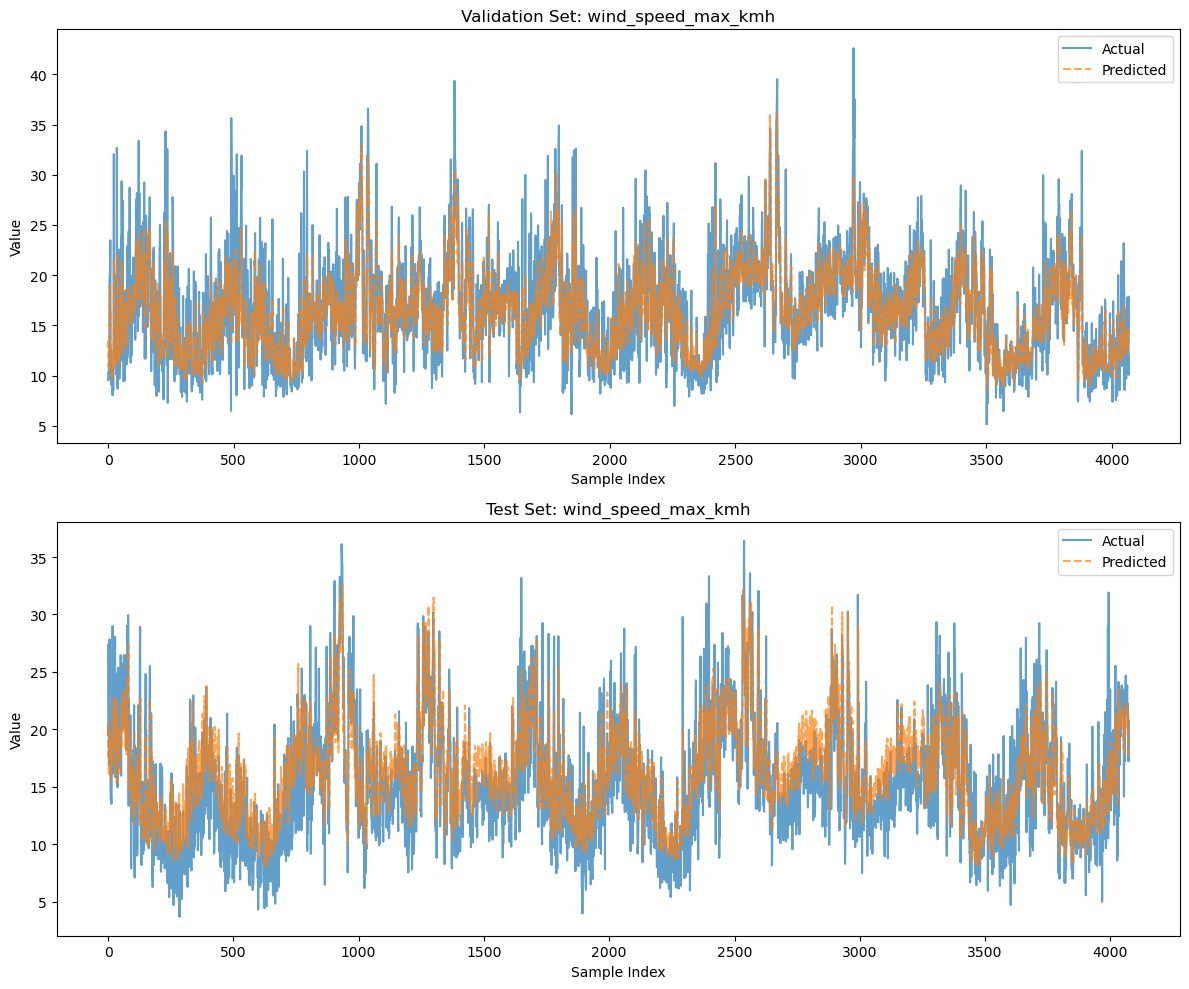

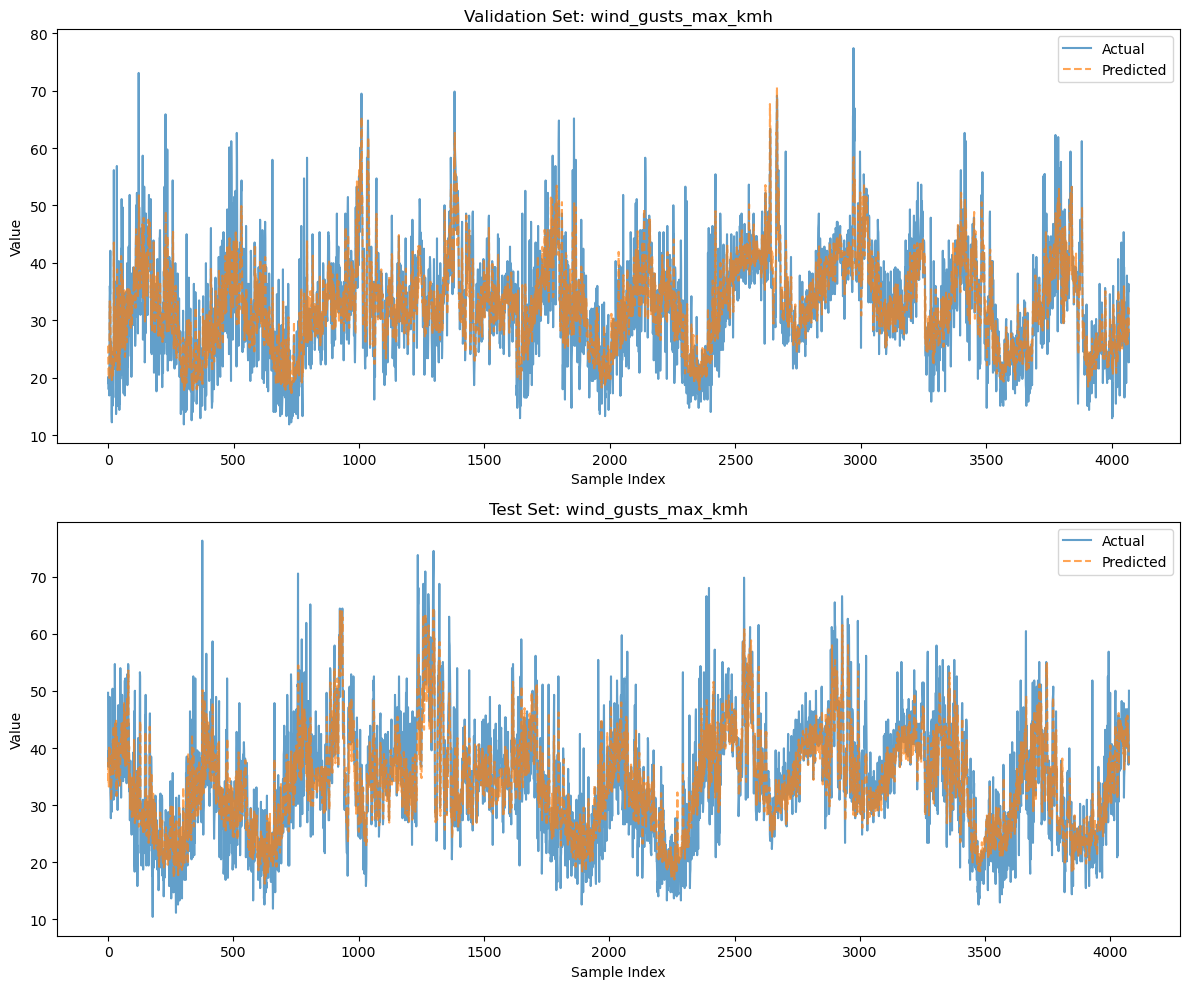

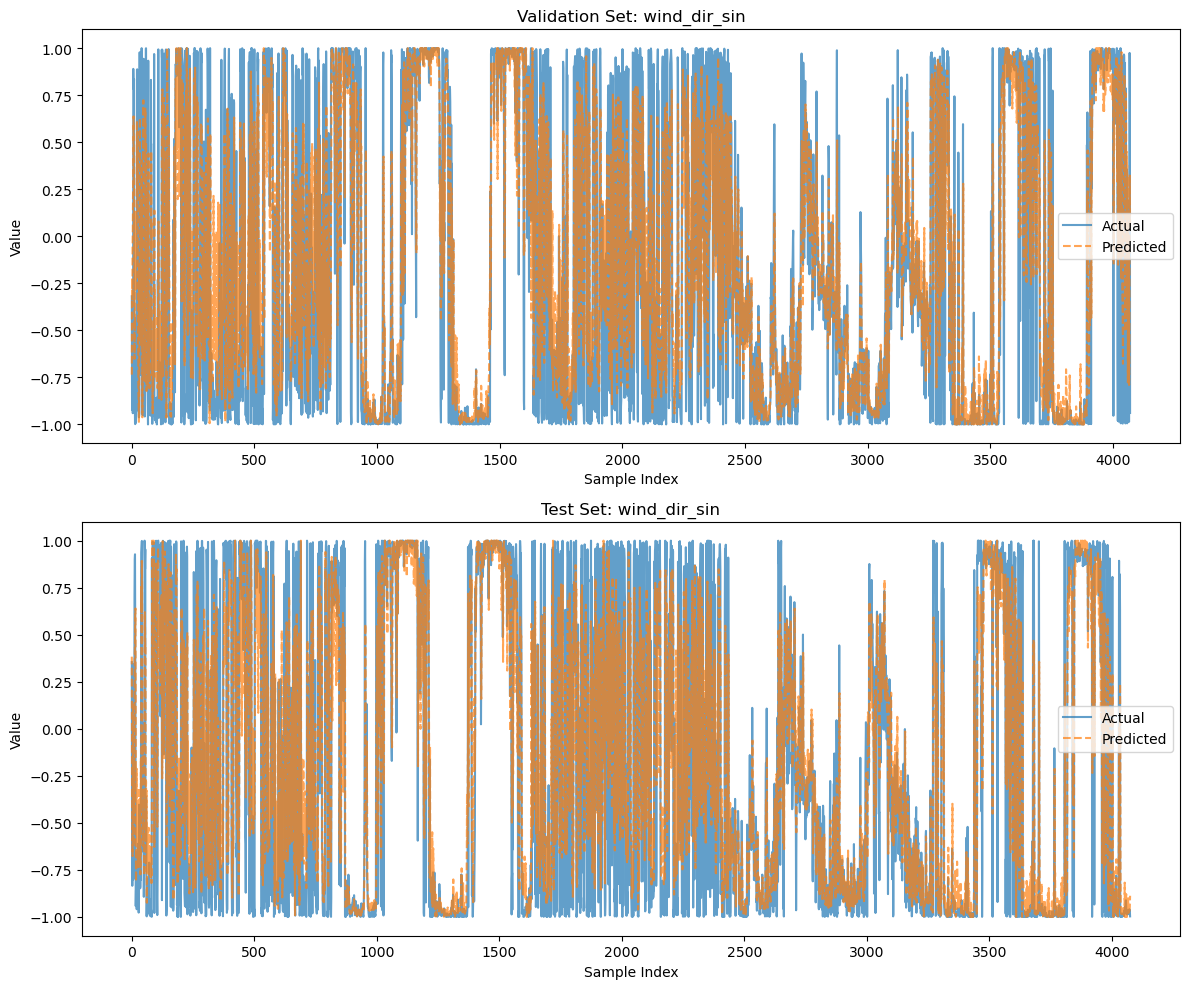

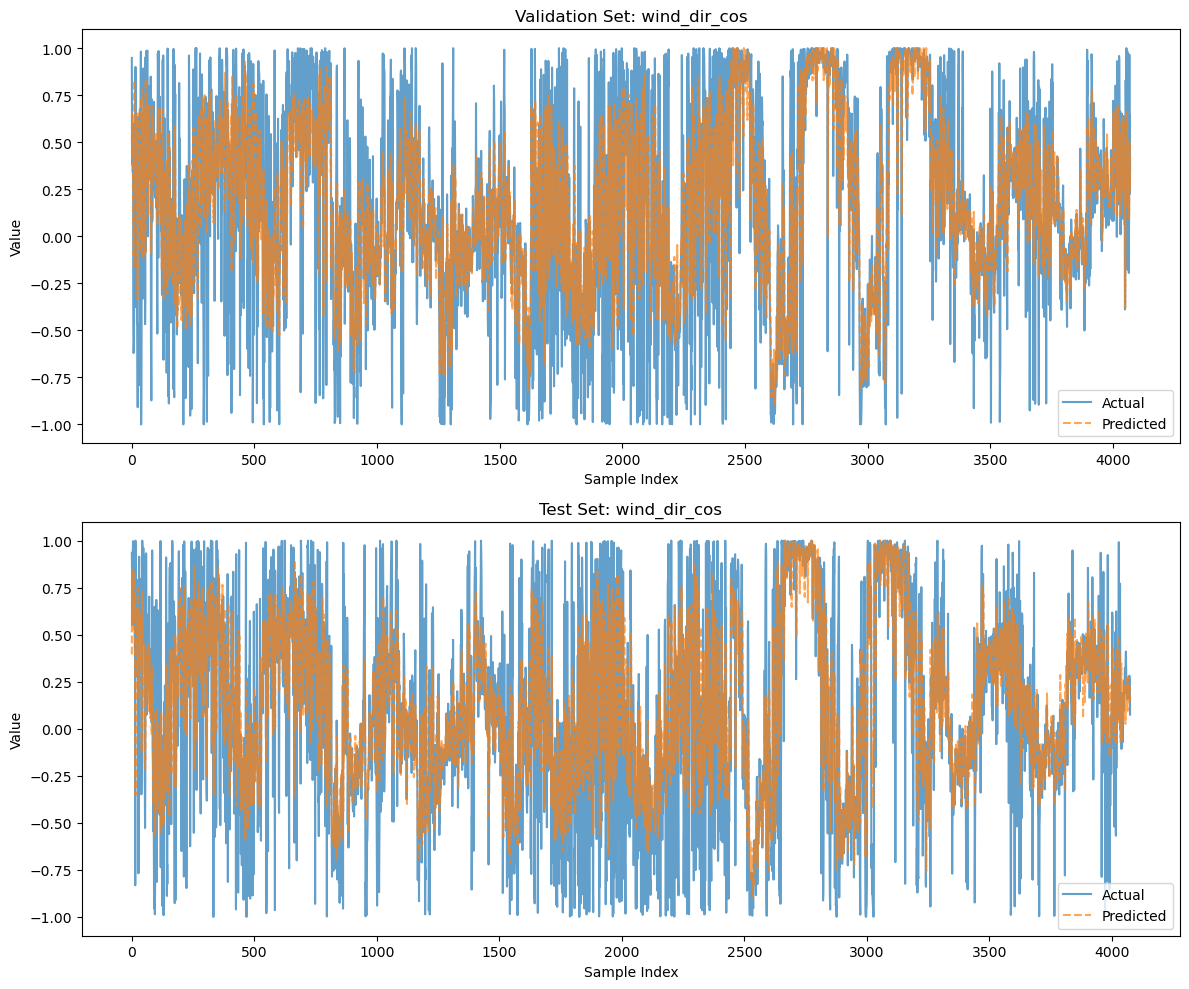

In [44]:
import matplotlib.pyplot as plt

# Generate and save comparison plots for each target
for target in targets:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Validation Plot
    # We use .values to extract the numpy array from the pandas series
    axes[0].plot(y_val[target].values, label='Actual', alpha=0.7)
    axes[0].plot(val_preds_dict[target], label='Predicted', alpha=0.7, linestyle='--')
    axes[0].set_title(f'Validation Set: {target}')
    axes[0].set_xlabel('Sample Index')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    
    # Test Plot
    axes[1].plot(y_test[target].values, label='Actual', alpha=0.7)
    axes[1].plot(test_preds_dict[target], label='Predicted', alpha=0.7, linestyle='--')
    axes[1].set_title(f'Test Set: {target}')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Value')
    axes[1].legend()
    
    plt.tight_layout()
    # Save the plot to your local directory
    plt.savefig(f'predicted_vs_real_{target}.png')
    plt.show() # Display in the notebook

In [46]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure your pipeline is ready
trained_models = {}
train_preds_dict = {}
val_preds_dict = {}
test_preds_dict = {}

for target in targets:
    obj = target_objectives[target]
    
    # DART configuration
    lgb_params = {
        'objective':         obj,
        'boosting_type':     'dart',   
        'learning_rate':     0.01,
        'n_estimators':      1000,    # Reduced slightly as DART trains slower
        'num_leaves':        15,
        'max_depth':         6,
        'min_child_samples': 80,
        'subsample':         0.7,
        'colsample_bytree':  0.7,
        'reg_alpha':         5,
        'reg_lambda':        10,
        'min_split_gain':    0.1,      
        'max_bin':           150,      
        'path_smooth':       0.1,      
        'drop_rate':         0.1,      
        'skip_drop':         0.5,      
        'random_state':      42,
        'n_jobs':            -1,
    }

    if obj == 'tweedie':
        lgb_params['tweedie_variance_power'] = 1.5

    model = LGBMRegressor(**lgb_params)

    # DART does not support early stopping. We fit without callbacks.
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_val, y_val[target])],
        verbose=False 
    )

    trained_models[target]    = model
    train_preds_dict[target]  = model.predict(X_train)
    val_preds_dict[target]    = model.predict(X_val)
    test_preds_dict[target]   = model.predict(X_test)

# Post-Processing: Physical Clipping
def clip_predictions(preds_dict):
    clipped = {}
    for tgt, pred in preds_dict.items():
        if 'speed' in tgt or 'gust' in tgt:
            clipped[tgt] = np.clip(pred, a_min=0, a_max=None)
        elif 'sin' in tgt or 'cos' in tgt:
            clipped[tgt] = np.clip(pred, a_min=-1, a_max=1)
    return clipped

train_preds_dict = clip_predictions(train_preds_dict)
val_preds_dict   = clip_predictions(val_preds_dict)
test_preds_dict  = clip_predictions(test_preds_dict)

# Evaluation
def evaluate_split(y_true, preds_dict, split_name):
    records = []
    for target in targets:
        true = y_true[target]
        pred = preds_dict[target]
        
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, pred)
        
        records.append({
            'Target': target, 'Split': split_name,
            'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2
        })
    return records

all_records = []
all_records.extend(evaluate_split(y_train, train_preds_dict, 'Train'))
all_records.extend(evaluate_split(y_val, val_preds_dict, 'Validation'))
all_records.extend(evaluate_split(y_test, test_preds_dict, 'Test'))

comparison_df = pd.DataFrame(all_records).set_index(['Target', 'Split'])
print("=== Train vs Validation vs Test Comparison (DART Mode) ===")
print(comparison_df.round(4))

TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'verbose'

In [ ]:
## 